In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


In [67]:
data_folder = '/Users/benny/swc/agents/data/split_cost_results_260707'
solo_files = identify_filepaths.get_relative_paths('solo', data_folder)

In [68]:
len(solo_files)

40

In [69]:
df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

IntProgress(value=0, max=40)

filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_0/2026-06-25_22-38-05_solo.json
Loading complete.
332477 332711
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_1/2026-06-26_04-04-58_solo.json
Loading complete.
331309 331022
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_2/2026-06-26_09-30-23_solo.json
Loading complete.
331505 331269
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_4/2026-06-26_20-22-51_solo.json
Loading complete.
329899 330117
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_5/2026-06-27_01-51-03_solo.json
Loading complete.
329530 317460
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_6/2026-06-27_07-15-15_solo.json
Loading complete.
331191 331392
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/s

In [70]:
dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

In [71]:
dropped_trials = 1
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 655
First trial end event found at index: 555
First trial end event found at index: 621
First trial end event found at index: 638
First trial end event found at index: 605
First trial end event found at index: 655
First trial end event found at index: 688
First trial end event found at index: 655
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at index: 671
First trial end event found at index: 605
First trial end event found at index: 2288
First trial end event found at index: 605
First trial end event found at index: 588
First trial end event found at index: 688
First trial end event found at index: 721
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 555
First trial end event found at index: 588
First trial end event found at index: 555
First trial end event found at index: 521
First trial end event found at in

In [72]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

In [247]:
import agent_analysis.functions.preprocessing as prep

_, step_penalties, thetas = prep.extract_step_penalties(data_folder, yaml_filename=None)
len(thetas)

No YAML file in excluded


40

## Session trajectories

In [87]:
# High translation / low turning first; low translation / high turning last
sorted_trials = sorted(
    zip(thetas, dfs_cropped),
    key=lambda x: x[0][0] / x[0][1] if x[0][1] != 0 else float("inf"),
    reverse=True
)

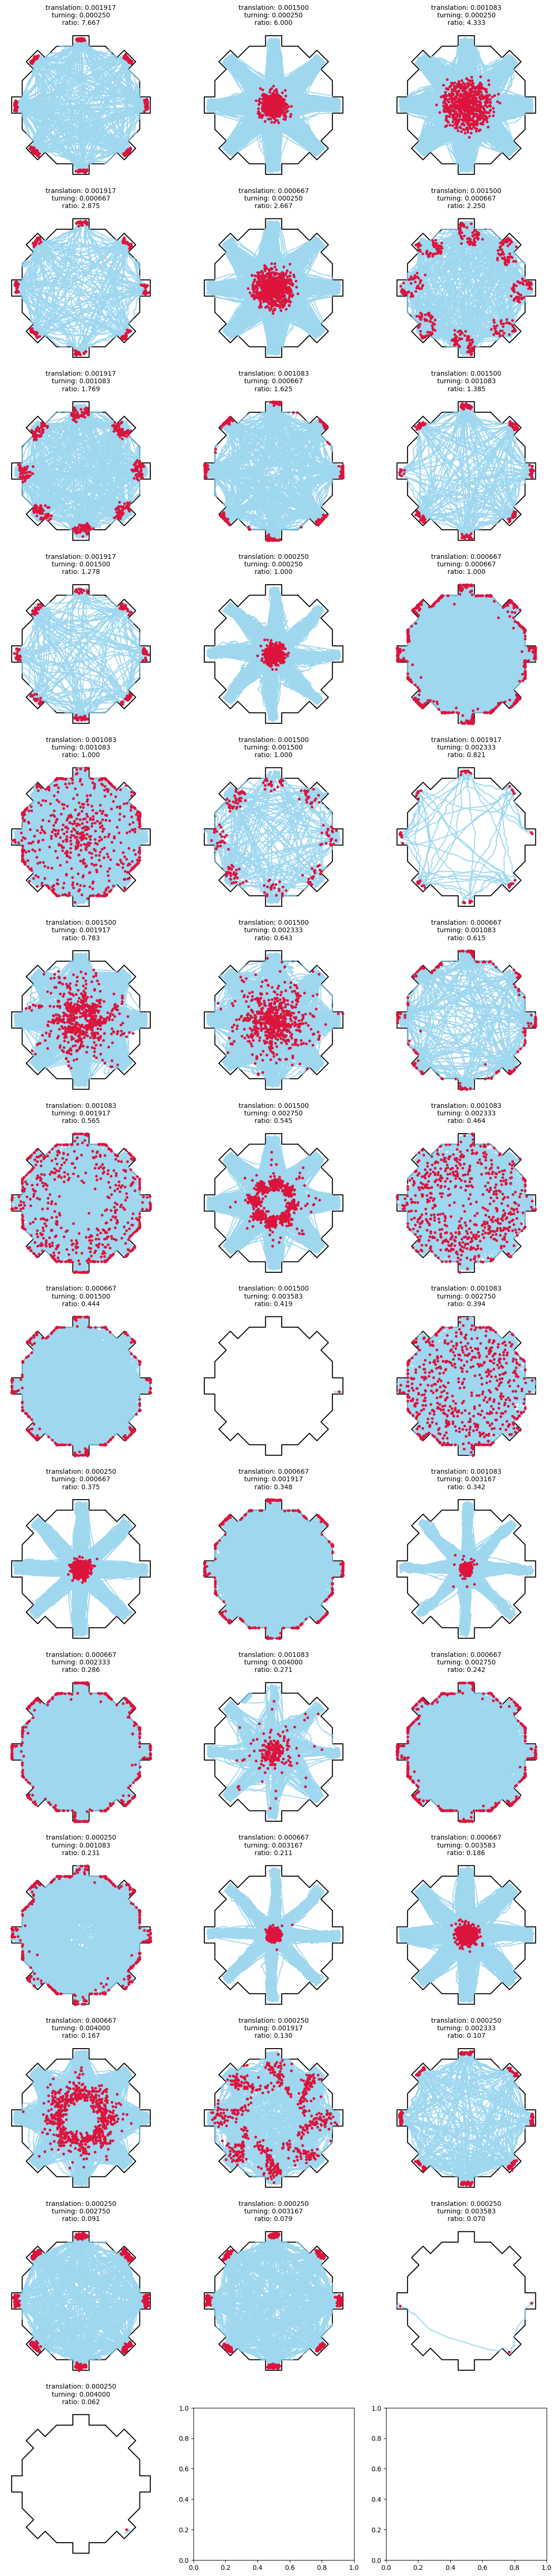

In [91]:
import matplotlib.pyplot as plt

num_lists = len(dfs_cropped)
num_cols = 3
num_rows = (num_lists + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))

axes = axes.flatten()

for i, (penalty, trial_list) in enumerate(sorted_trials):
    translation_cost, turning_cost = penalty
    ratio = translation_cost / turning_cost if turning_cost != 0 else float("inf")

    ax = plot_octagon.plot_octagon(ax=axes[i])
    plot_trajectory.plot_session_trajectory(
        ax,
        trial_list,
        colour_player_1='skyblue',
        alpha=0.8,
        slice_onset_markers=True
    )
    plot_trajectory.mark_session_slice_onsets(
        ax,
        trial_list,
        chosen_player=0,
        color='crimson'
    )

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(
        f'translation: {translation_cost:.6f}\n'
        f'turning: {turning_cost:.6f}\n'
        f'ratio: {ratio:.3f}',
        fontsize=10
    )

In [103]:
(0.001/2)/2

0.00025

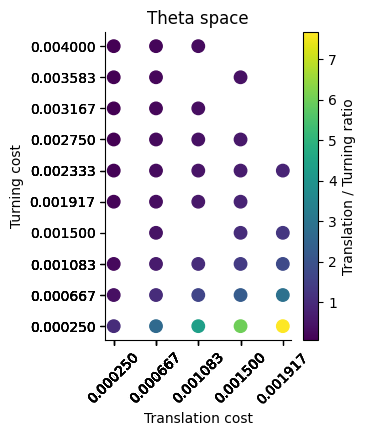

In [109]:
translation_costs = np.array([t[0] for t in thetas])
turning_costs = np.array([t[1] for t in thetas])
ratios = translation_costs / turning_costs

fig, ax = plt.subplots(figsize=(3, 4))

sc = ax.scatter(
    translation_costs,
    turning_costs,
    c=ratios,
    cmap="viridis",
    s=80
)

plt.colorbar(sc, ax=ax, label="Translation / Turning ratio")

#for i, (x, y) in enumerate(zip(translation_costs, turning_costs)):
#    ax.text(x, y, str(i), fontsize=8)

translation_costs = np.array([t[0] for t in thetas])
turning_costs = np.array([t[1] for t in thetas])

ax.tick_params(axis='x', rotation=45)

ax.set_xticks(translation_costs)
ax.set_yticks(turning_costs)

ax.set_xlabel("Translation cost")
ax.set_ylabel("Turning cost")
ax.set_title("Theta space")

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

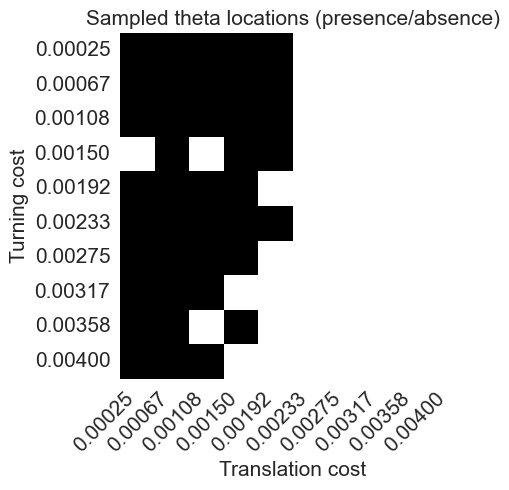

In [276]:
theta_df = pd.DataFrame({
    "translation": [t[0] for t in thetas],
    "turning": [t[1] for t in thetas],
})

# Define the full intended parameter range
translation_grid = np.linspace(0.00025, 0.004, 10)
turning_grid = np.linspace(0.00025, 0.004, 10)

# Count sampled thetas
count_table = theta_df.pivot_table(
    index="turning",
    columns="translation",
    aggfunc="size",
    fill_value=0
)

# Force heatmap to include unsampled grid locations
count_table = count_table.reindex(
    index=turning_grid,
    columns=translation_grid,
    fill_value=0
)

presence_table = count_table > 0

fig, ax = plt.subplots(figsize=(5, 5))

sns.heatmap(
    #count_table,
    presence_table,
    #cmap="viridis",
    cmap="Greys",

    square=True,
    ax=ax,
    #cbar_kws={"label": "Number of agents"},
    cbar=False
)

ax.set_xticklabels([f"{x:.5f}" for x in count_table.columns], rotation=45, ha="right", fontsize=15)
ax.set_yticklabels([f"{y:.5f}" for y in count_table.index], rotation=0, fontsize=15)

ax.set_xlabel("Translation cost", fontsize=15)
ax.set_ylabel("Turning cost", fontsize=15)
ax.set_title("Sampled theta locations (presence/absence)", fontsize=15)

plt.tight_layout()
plt.show()

## P(High) across models

In [ ]:
# create empty dictionary

analysis_results = {
    session_id: {

            # trial list and filtered trial indices
            'trial_lists': {
                'full_session': None
            },

            # chosen wall numbers and whether high or low
            'choice_data' : {
                'wall_numbers': None,
                'chose_high': None,
                'probability_chose_high': None  # array of values from walls 1 to 8
            }
            

        }
    for session_id in np.arange(len(trial_lists))
}

In [ ]:
# assign trial lists

for session_id in analysis_results.keys():

    print(f"\n\nProcessing session: {session_id}\n\n")
    player_data = analysis_results[session_id]
    trial_list = trial_lists[session_id]
    print(f"Number of trials in full session: {len(trial_list)}")


    player_data['trial_lists']['full_session'] = trial_list



Processing session: 0


Number of trials in full session: 718


Processing session: 1


Number of trials in full session: 726


Processing session: 2


Number of trials in full session: 721


Processing session: 3


Number of trials in full session: 657


Processing session: 4


Number of trials in full session: 223


Processing session: 5


Number of trials in full session: 605


Processing session: 6


Number of trials in full session: 599


Processing session: 7


Number of trials in full session: 604


Processing session: 8


Number of trials in full session: 596


Processing session: 9


Number of trials in full session: 725


Processing session: 10


Number of trials in full session: 720


Processing session: 11


Number of trials in full session: 698


Processing session: 12


Number of trials in full session: 528


Processing session: 13


Number of trials in full session: 700


Processing session: 14


Number of trials in full session: 541


Processing session: 15


Number o

In [115]:
# find chosen wall numbers and whether high or low

for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    trial_list = player_data['trial_lists']['full_session']

    player_data['choice_data']['wall_numbers'] = get_indices.get_chosen_walls(trial_list).astype(int)
    player_data['choice_data']['chose_high'] = get_indices.was_high_wall_chosen(trial_list)


    # print(len(player_data['choice_data']['chose_high']))

In [124]:
for session_id in analysis_results.keys():

    print(session_id)
    
    player_data = analysis_results[session_id]
    wall_numbers = player_data['choice_data']['wall_numbers']
    chose_high = player_data['choice_data']['chose_high']

    print(f"Wall numbers: {wall_numbers}")
    print(f"Chose high: {chose_high}")

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    mask = counts > 4  # Ensure at least 5 trials per wall to calculate probability
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    player_data['choice_data']['probability_chose_high'] = wall_probabilities

0
Wall numbers: [4 3 8 6 5 6 8 3 7 1 6 4 3 8 8 4 2 7 8 8 3 4 1 5 1 6 8 4 4 3 3 7 2 6 1 5 2
 5 5 7 8 6 5 6 7 6 1 3 8 2 6 2 7 1 1 7 5 4 7 8 2 4 2 2 1 7 8 3 4 3 2 1 1 1
 2 1 8 8 4 4 3 5 4 6 1 2 2 2 6 7 8 3 6 5 6 3 1 6 2 4 6 7 3 3 4 4 5 2 2 7 8
 3 4 8 5 3 6 3 5 1 2 7 6 2 3 8 3 6 4 1 2 6 2 8 1 7 5 7 6 8 5 3 5 7 6 3 1 5
 7 7 7 8 2 8 6 6 2 4 5 2 6 2 4 4 7 6 1 2 7 6 7 6 1 8 4 1 2 1 7 7 3 2 7 5 4
 7 1 4 3 5 2 2 8 2 2 4 8 5 2 5 4 2 8 4 5 2 5 4 2 5 2 7 2 8 4 3 4 8 5 7 5 7
 5 7 2 7 7 6 6 5 1 4 8 7 7 1 7 1 2 1 5 6 8 4 7 7 5 6 2 5 5 5 6 5 8 6 7 2 3
 4 8 7 6 8 2 5 6 5 2 4 6 1 3 6 8 2 4 8 4 7 8 4 4 1 1 8 2 4 3 3 8 5 4 8 6 3
 6 5 7 5 3 4 1 7 7 3 6 7 8 2 6 2 5 5 5 2 7 2 4 5 1 4 7 1 5 7 6 4 7 6 3 8 2
 1 4 6 4 2 2 7 4 5 5 8 1 7 7 4 4 3 6 4 4 4 5 3 1 4 8 5 8 8 5 8 6 6 6 8 5 4
 2 2 4 3 6 1 6 3 6 2 6 4 6 7 5 8 8 7 6 8 2 8 8 2 1 4 1 5 1 3 2 2 1 4 5 6 3
 8 1 1 2 4 3 2 6 3 2 7 4 3 1 8 2 3 2 7 1 7 7 7 1 7 6 7 6 3 4 8 4 7 5 4 3 2
 2 7 2 6 4 4 8 7 5 4 5 2 1 8 6 5 8 7 7 5 5 7 7 5 7 5 2 6 7 6 3 5 4 1 1 3 3
 4 2 3 2 

In [125]:
# High translation / low turning first; low translation / high turning last
sorted_sessions = sorted(
    zip(thetas, analysis_results.keys()),
    key=lambda x: x[0][0] / x[0][1] if x[0][1] != 0 else float("inf"),
    reverse=True
)

Average P(High) for session 30 (translation, turning costs: 0.001917, 0.000250): 0.793
Average P(High) for session 21 (translation, turning costs: 0.001500, 0.000250): 1.000
Average P(High) for session 13 (translation, turning costs: 0.001083, 0.000250): 0.848
Average P(High) for session 31 (translation, turning costs: 0.001917, 0.000667): 0.759
Average P(High) for session 2 (translation, turning costs: 0.000667, 0.000250): 0.874
Average P(High) for session 22 (translation, turning costs: 0.001500, 0.000667): 0.852
Average P(High) for session 32 (translation, turning costs: 0.001917, 0.001083): 0.931
Average P(High) for session 14 (translation, turning costs: 0.001083, 0.000667): 0.578
Average P(High) for session 23 (translation, turning costs: 0.001500, 0.001083): 0.787
Average P(High) for session 33 (translation, turning costs: 0.001917, 0.001500): 0.799
Average P(High) for session 0 (translation, turning costs: 0.000250, 0.000250): 1.000
Average P(High) for session 3 (translation, t

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_37980/3472458536.py:28: RuntimeWarning: Mean of empty slice
  avg_p_high = np.nanmean(wall_probabilities)


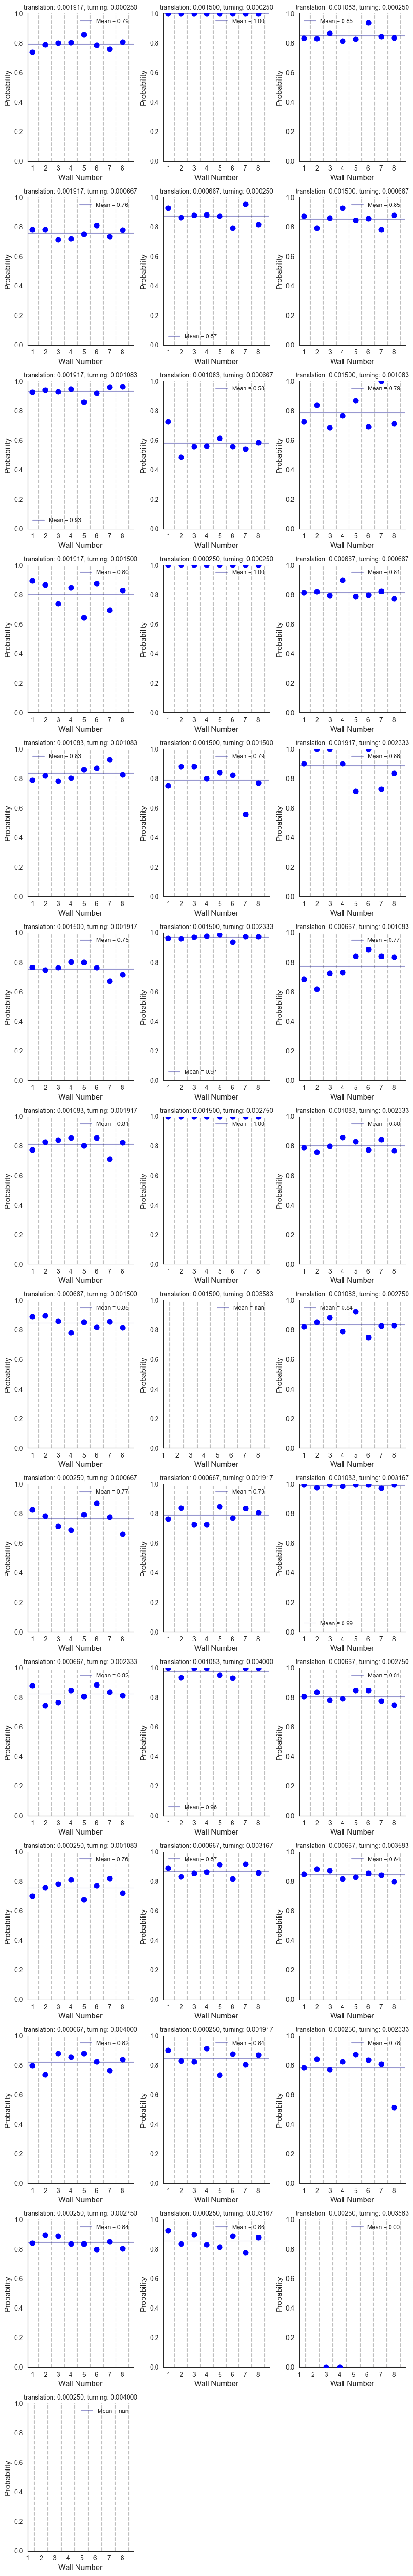

In [136]:
num_sessions = len(analysis_results)
num_cols = 3
num_rows = (num_sessions + num_cols - 1) // num_cols  # ceiling division
fig, axes = plt.subplots(num_rows, num_cols, figsize=(3*num_cols, 4*num_rows))

axes = axes.flatten()

for i, (thetas, session_id) in enumerate(sorted_sessions):
    ax = axes[i]
    
    wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']]
    chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']]

    wall_numbers = np.concatenate(wall_number_list).astype(int)
    chose_high = np.concatenate(chose_high_list)

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    # Print average P(High) across walls for each session
    avg_p_high = np.nanmean(wall_probabilities)
    print(f"Average P(High) for session {session_id} (translation, turning costs: {thetas[0]:.6f}, {thetas[1]:.6f}): {avg_p_high:.3f}")

    wall_numbers_plot = np.arange(1,9)
    
    # set seaborn style
    sns.set_style("white", {"axes.grid": False})

    # plot vertical dashed grey lines for each categorical x value
    for x in wall_numbers_plot:
        ax.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

    # plot individual wall probabilities
    ax.scatter(
        wall_numbers_plot,
        wall_probabilities,
        color="blue",
        s=60,
        zorder=3
    )

    # plot average probability as a horizontal line
    ax.axhline(
        avg_p_high,
        color="darkblue",
        linestyle="-",
        linewidth=1.5,
        alpha=0.4,
        label=f"Mean = {avg_p_high:.2f}"
    )

    ax.legend(frameon=False, fontsize=9)

    # Customize labels and title
    ax.set_xlabel("Wall Number", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.set_title(f'translation: {thetas[0]:.6f}, turning: {thetas[1]:.6f}', fontsize=10)

    # set y-axis for probability
    ax.set_ylim([0,1])

    # adjust x-axis ticks to match categorical values
    ax.set_xticks(wall_numbers_plot)

    # Remove top and right borders
    sns.despine(ax=ax, top=True, right=True)

for j in range(num_sessions, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [228]:
translation_costs = []
turning_costs = []
avg_p_high_list = []
ratios = []

for thetas, session_id in sorted_sessions:

    translation_costs.append(thetas[0])
    turning_costs.append(thetas[1])

    ratio = thetas[0] / thetas[1]   # translation / turning
    ratios.append(ratio)

    wall_probabilities = analysis_results[session_id]['choice_data']['probability_chose_high']
    avg_p_high_list.append(np.nanmean(wall_probabilities))

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_37980/1272802619.py:15: RuntimeWarning: Mean of empty slice
  avg_p_high_list.append(np.nanmean(wall_probabilities))


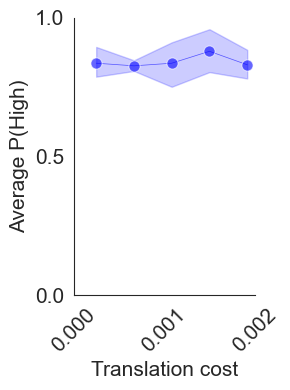

In [213]:
plt.figure(figsize=(3, 4))

sns.lineplot(
    x=translation_costs,
    y=avg_p_high_list,
    marker="o",
    linewidth=0.5,
    markersize=8,
    color="blue",
    alpha=0.6
)

plt.xticks(np.arange(0, max(translation_costs) + 0.0001, 0.001), fontsize=15, rotation=45)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)

plt.xlabel("Translation cost", fontsize=15)
plt.ylabel("Average P(High)", fontsize=15)

sns.despine()
plt.tight_layout()
plt.show()

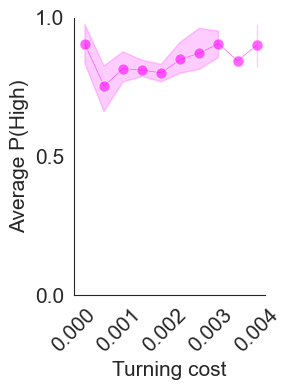

In [211]:
plt.figure(figsize=(3, 4))

sns.lineplot(
    x=turning_costs,
    y=avg_p_high_list,
    linewidth=0.5,
    marker="o",
    markersize=8,
    color="magenta",
    alpha=0.6
)

plt.xlabel("Turning cost", fontsize=15)
plt.ylabel("Average P(High)", fontsize=15)
plt.xticks(np.arange(0, max(turning_costs) + 0.0001, 0.001), fontsize=15, rotation=45)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)
sns.despine()
plt.tight_layout()
plt.show()

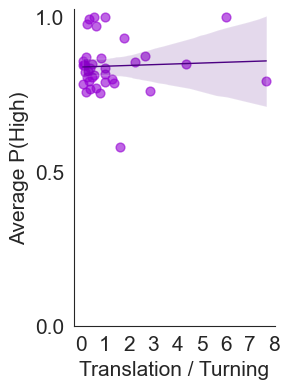

In [238]:
plt.figure(figsize=(3, 4))

sns.regplot(
    x=ratios,
    y=avg_p_high_list,
    scatter_kws={"color": "darkviolet", "s": 40, "alpha": 0.6},
    line_kws={"color": "indigo", "linewidth": 1},
    ci=95,
)

plt.xticks(np.arange(0, max(ratios) + 1, 1), fontsize=15)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)

plt.xlabel("Translation / Turning", fontsize=15)
plt.ylabel("Average P(High)", fontsize=15)

sns.despine()
plt.tight_layout()
plt.show()

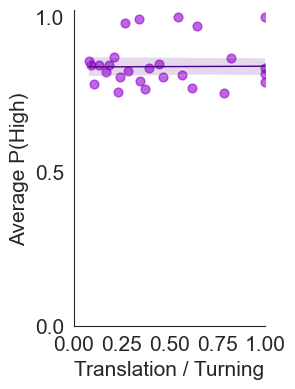

In [242]:
plt.figure(figsize=(3, 4))

sns.regplot(
    x=ratios,
    y=avg_p_high_list,
    scatter_kws={"color": "darkviolet", "s": 40, "alpha": 0.6},
    line_kws={"color": "indigo", "linewidth": 1},
    ci=95,
)

plt.xlim(0.0, 1)

plt.xticks(fontsize=15)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)

plt.xlabel("Translation / Turning", fontsize=15)
plt.ylabel("Average P(High)", fontsize=15)

sns.despine()
plt.tight_layout()
plt.show()